**1**

In [1]:
%pip install -q numpy pandas matplotlib seaborn soundfile scipy librosa tqdm scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**2**

In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import librosa
from scipy import signal
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

print("Libraries loaded.")

Libraries loaded.


**3**

In [3]:
PROJECT_DIR = Path.cwd().resolve()

# If the notebook is not opened from the SHL_Audio project root, set the full path:
# PROJECT_DIR = Path(r"D:/Your/Path/SHL_Audio")

DATA_DIR = PROJECT_DIR / "Dataset_Final"
TRAIN_AUDIO_DIR = DATA_DIR / "train"
TEST_AUDIO_DIR = DATA_DIR / "test"
FEATURE_DIR = PROJECT_DIR / "features"
OUTPUT_DIR = PROJECT_DIR / "outputs"

FEATURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"

for path in [TRAIN_CSV, TEST_CSV, TRAIN_AUDIO_DIR, TEST_AUDIO_DIR]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required path not found: {path}\n"
            "Check PROJECT_DIR and the expected folder layout."
        )

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

required_train = {"filename", "label"}
required_test = {"filename"}
if not required_train.issubset(train_df.columns):
    raise ValueError(f"train.csv must contain {sorted(required_train)}")
if not required_test.issubset(test_df.columns):
    raise ValueError(f"test.csv must contain {sorted(required_test)}")

train_df["label"] = pd.to_numeric(train_df["label"], errors="raise")

print(f"Project: {PROJECT_DIR}")
print(f"Training rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")

Project: C:\Users\USER\Documents\Python Rep\SHL_Audio
Training rows: 769
Test rows: 216


**4**

In [4]:
def resolve_paths(frame, audio_dir):
    paths = {}
    for filename in frame["filename"].astype(str):
        paths[filename] = audio_dir / filename
    return paths

train_paths = resolve_paths(train_df, TRAIN_AUDIO_DIR)
test_paths = resolve_paths(test_df, TEST_AUDIO_DIR)

missing_train = [name for name, path in train_paths.items() if not path.is_file()]
missing_test = [name for name, path in test_paths.items() if not path.is_file()]

print(f"Missing training audio: {len(missing_train)}")
print(f"Missing test audio: {len(missing_test)}")

if missing_train or missing_test:
    raise FileNotFoundError(
        "Some CSV filenames do not have matching WAV files in their respective split folders. "
        "Inspect the missing filename lists before continuing."
    )

Missing training audio: 0
Missing test audio: 0


5

In [5]:
def extract_audio_features(filename, path, split):
    # Load mono audio for consistent feature extraction. The original file is not changed.
    y, sr = librosa.load(path, sr=None, mono=True)

    if y.size == 0:
        raise ValueError("Audio file contains no samples.")

    duration = len(y) / sr
    frame_length = 2048
    hop_length = 512

    # Avoid invalid settings on unusually short recordings.
    if len(y) < frame_length:
        y = np.pad(y, (0, frame_length - len(y)))

    rms = librosa.feature.rms(
        y=y, frame_length=frame_length, hop_length=hop_length
    )[0]
    zcr = librosa.feature.zero_crossing_rate(
        y, frame_length=frame_length, hop_length=hop_length
    )[0]
    centroid = librosa.feature.spectral_centroid(
        y=y, sr=sr, n_fft=frame_length, hop_length=hop_length
    )[0]
    bandwidth = librosa.feature.spectral_bandwidth(
        y=y, sr=sr, n_fft=frame_length, hop_length=hop_length
    )[0]
    rolloff = librosa.feature.spectral_rolloff(
        y=y, sr=sr, n_fft=frame_length, hop_length=hop_length, roll_percent=0.85
    )[0]

    # Low-energy frames are only a rough proxy for silence/pauses.
    energy_threshold = max(float(np.max(rms)) * 0.08, 1e-5)
    low_energy_ratio = float(np.mean(rms < energy_threshold))

    # Pitch is estimated with pYIN. Keep valid voiced estimates only.
    try:
        f0, voiced_flag, voiced_prob = librosa.pyin(
            y,
            fmin=librosa.note_to_hz("C2"),
            fmax=librosa.note_to_hz("C7"),
            sr=sr,
            frame_length=frame_length,
            hop_length=hop_length,
        )
        voiced_f0 = f0[np.isfinite(f0)]
        pitch_median = float(np.median(voiced_f0)) if voiced_f0.size else np.nan
        pitch_std = float(np.std(voiced_f0)) if voiced_f0.size else np.nan
        pitch_iqr = (
            float(np.percentile(voiced_f0, 75) - np.percentile(voiced_f0, 25))
            if voiced_f0.size else np.nan
        )
        voiced_ratio = float(np.isfinite(f0).mean())
    except Exception:
        pitch_median = np.nan
        pitch_std = np.nan
        pitch_iqr = np.nan
        voiced_ratio = np.nan

    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=13, n_fft=frame_length, hop_length=hop_length
    )

    features = {
        "filename": filename,
        "split": split,
        "duration_seconds": duration,
        "sample_rate": sr,
        "signal_rms_mean": float(np.mean(rms)),
        "signal_rms_std": float(np.std(rms)),
        "signal_peak_abs": float(np.max(np.abs(y))),
        "low_energy_frame_ratio": low_energy_ratio,
        "voiced_frame_ratio": voiced_ratio,
        "pitch_median_hz": pitch_median,
        "pitch_std_hz": pitch_std,
        "pitch_iqr_hz": pitch_iqr,
        "zero_crossing_rate_mean": float(np.mean(zcr)),
        "zero_crossing_rate_std": float(np.std(zcr)),
        "spectral_centroid_mean": float(np.mean(centroid)),
        "spectral_centroid_std": float(np.std(centroid)),
        "spectral_bandwidth_mean": float(np.mean(bandwidth)),
        "spectral_bandwidth_std": float(np.std(bandwidth)),
        "spectral_rolloff_mean": float(np.mean(rolloff)),
        "spectral_rolloff_std": float(np.std(rolloff)),
    }

    for index in range(mfcc.shape[0]):
        features[f"mfcc_{index + 1:02d}_mean"] = float(np.mean(mfcc[index]))
        features[f"mfcc_{index + 1:02d}_std"] = float(np.std(mfcc[index]))

    return features

6

In [6]:
FEATURE_CACHE = FEATURE_DIR / "audio_features.csv"

if FEATURE_CACHE.is_file():
    cached = pd.read_csv(FEATURE_CACHE)
    completed = set(zip(cached["split"].astype(str), cached["filename"].astype(str)))
    feature_rows = cached.to_dict("records")
else:
    cached = pd.DataFrame()
    completed = set()
    feature_rows = []

tasks = [
    ("train", name, path) for name, path in train_paths.items()
] + [
    ("test", name, path) for name, path in test_paths.items()
]

errors = []
for split, filename, path in tqdm(tasks, desc="Extracting audio features"):
    if (split, filename) in completed:
        continue

    try:
        row = extract_audio_features(filename, path, split)
        feature_rows.append(row)
        completed.add((split, filename))
    except Exception as exc:
        errors.append({"split": split, "filename": filename, "error": str(exc)})

    # Save periodically to protect work if a file or kernel fails.
    if len(feature_rows) % 10 == 0:
        pd.DataFrame(feature_rows).to_csv(FEATURE_CACHE, index=False)

features_df = pd.DataFrame(feature_rows)
features_df = features_df.drop_duplicates(subset=["split", "filename"], keep="last")
features_df.to_csv(FEATURE_CACHE, index=False)

errors_df = pd.DataFrame(errors)
if not errors_df.empty:
    errors_df.to_csv(FEATURE_DIR / "audio_feature_errors.csv", index=False)

print(f"Feature rows saved: {len(features_df)}")
print(f"Extraction errors this run: {len(errors_df)}")
print(f"Feature cache: {FEATURE_CACHE}")
if not errors_df.empty:
    display(errors_df.head(20))

Extracting audio features:   0%|          | 0/985 [00:00<?, ?it/s]

Feature rows saved: 985
Extraction errors this run: 0
Feature cache: C:\Users\USER\Documents\Python Rep\SHL_Audio\features\audio_features.csv


7

In [7]:
display(features_df.head())
print("Feature table shape:", features_df.shape)

feature_columns = [
    column for column in features_df.columns
    if column not in {"filename", "split"}
]

missing_summary = (
    features_df[feature_columns]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)
display(missing_summary.head(15))

display(
    features_df.groupby("split")[feature_columns]
    .agg(["mean", "std"])
    .T
    .head(30)
)

,filename,split,duration_seconds,sample_rate,signal_rms_mean,signal_rms_std,signal_peak_abs,low_energy_frame_ratio,voiced_frame_ratio,pitch_median_hz,pitch_std_hz,pitch_iqr_hz,zero_crossing_rate_mean,zero_crossing_rate_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,mfcc_01_mean,mfcc_01_std,mfcc_02_mean,mfcc_02_std,mfcc_03_mean,mfcc_03_std,mfcc_04_mean,mfcc_04_std,mfcc_05_mean,mfcc_05_std,mfcc_06_mean,mfcc_06_std,mfcc_07_mean,mfcc_07_std,mfcc_08_mean,mfcc_08_std,mfcc_09_mean,mfcc_09_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,audio_192.wav,train,60.508375,16000,0.031786,0.038404,0.477783,0.503966,0.606029,169.643191,22.624346,17.646101,0.084768,0.053518,979.478539,399.567888,916.472067,261.620566,1770.739688,661.667662,-403.835907,121.629189,103.576340,68.035645,-14.213533,37.100349,16.673616,21.843693,7.048550,11.192187,-4.999640,14.073897,5.885732,10.086836,-9.268934,11.238889,-8.681059,9.175092,-6.111350,7.005802,-11.947043,8.755230,-8.226156,6.883492,-6.238204,5.747041
1,audio_436.wav,train,60.074688,16000,0.068651,0.055423,0.945648,0.261981,0.862087,223.845532,49.712582,48.628632,0.142977,0.127519,1813.837012,1156.460316,1502.301143,495.435560,3277.169030,1860.128111,-287.111023,81.685997,72.087601,56.021065,5.334722,46.173588,24.854349,37.073082,-13.109429,27.177183,0.168592,19.531832,-15.632074,21.483662,-20.825958,19.237547,-6.671186,16.002325,-8.470199,13.448154,-9.261223,11.554406,-9.040758,13.295260,4.751498,13.532232
2,audio_447.wav,train,60.074688,16000,0.054421,0.051533,0.919312,0.358360,0.539404,143.478728,125.981816,20.797126,0.146870,0.129777,1652.475254,1207.838332,1500.652559,535.214385,2941.260650,2078.460142,-324.808197,86.514740,97.828194,59.010967,18.635786,30.665186,5.857049,28.117016,2.258683,18.588797,-16.368387,25.997847,-24.105774,24.626266,-6.395788,16.164936,-8.089577,16.530882,-8.570185,16.668097,3.306296,13.158398,-3.113312,11.855078,-0.866495,11.763124
3,audio_126.wav,train,45.060000,16000,0.013778,0.012183,0.328979,0.314407,0.714691,128.565497,72.208630,150.262481,0.059477,0.036870,996.631363,471.566967,1177.252185,392.434373,1865.640525,1171.358114,-489.320648,124.842316,111.792915,53.296013,0.751575,41.733730,33.133247,33.229671,8.309433,21.988726,8.676818,18.460913,-11.291533,19.099558,-20.012392,15.214678,-15.253531,15.149112,-21.515909,15.097207,-12.347360,11.821060,-9.993058,10.599061,-17.710949,11.394983
4,audio_61.wav,train,45.300000,16000,0.009330,0.008970,0.176147,0.361582,0.490819,120.650748,20.555275,24.572141,0.169988,0.128430,2278.144095,1068.412091,1630.415181,442.415960,4034.356241,1606.058056,-483.865997,159.520401,51.975899,58.754555,-21.642136,44.306683,31.146597,36.615963,-11.265674,24.949566,-14.069729,19.346073,-13.595560,18.474709,-16.988165,19.791796,-9.642052,16.179859,-18.795961,16.087769,-8.590364,13.599857,3.873606,10.692766,-17.764479,15.302751


Feature table shape: (985, 46)


,missing_count
duration_seconds,0
sample_rate,0
signal_rms_mean,0
signal_rms_std,0
signal_peak_abs,0
low_energy_frame_ratio,0
voiced_frame_ratio,0
pitch_median_hz,0
pitch_std_hz,0
pitch_iqr_hz,0


split                                 test         train
duration_seconds        mean     48.755341     55.781067
                        std       8.181578      7.908964
sample_rate             mean  16000.000000  16000.000000
                        std       0.000000      0.000000
signal_rms_mean         mean      0.035363      0.044749
                        std       0.024325      0.025061
signal_rms_std          mean      0.031077      0.039049
                        std       0.021102      0.016060
signal_peak_abs         mean      0.614789      0.753278
                        std       0.320871      0.247088
low_energy_frame_ratio  mean      0.327693      0.379252
                        std       0.154549      0.159762
voiced_frame_ratio      mean      0.656688      0.617416
                        std       0.133806      0.160523
pitch_median_hz         mean    163.561523    160.736563
                        std      47.166033     77.646037
pitch_std_hz            mean     63.981061    102.843108
                        std      75.986119    130.872241
pitch_iqr_hz            mean     32.794742     40.915848
                        std      27.355963     95.546175
zero_crossing_rate_mean mean      0.139168      0.161382
                        std       0.050481      0.081178
zero_crossing_rate_std  mean      0.103740      0.109389
                        std       0.036354      0.036816
spectral_centroid_mean  mean   1773.463461   1884.330029
                        std     413.209083    608.890371
spectral_centroid_std   mean    902.925654    947.535204
                        std     260.163620    315.750421
spectral_bandwidth_mean mean   1563.645041   1573.957445
                        std     227.356039    302.608792

8

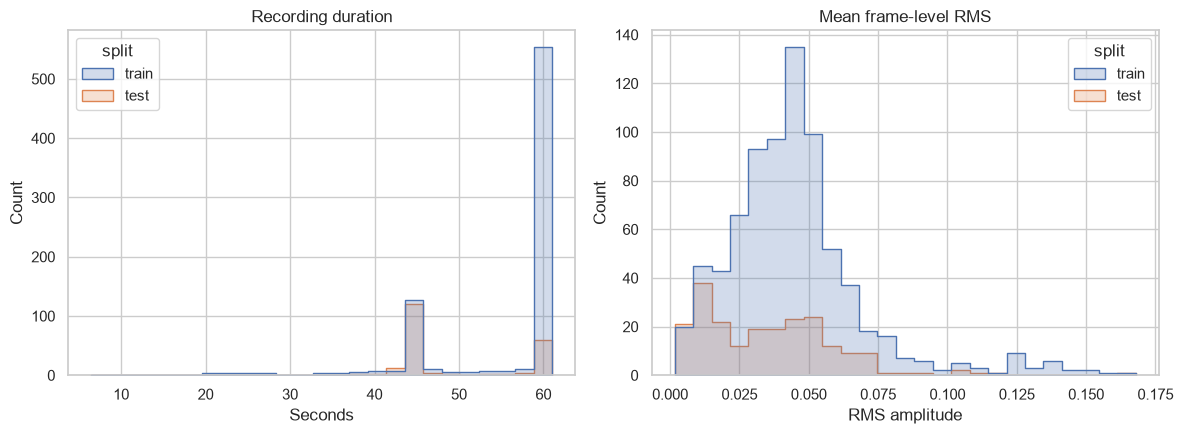

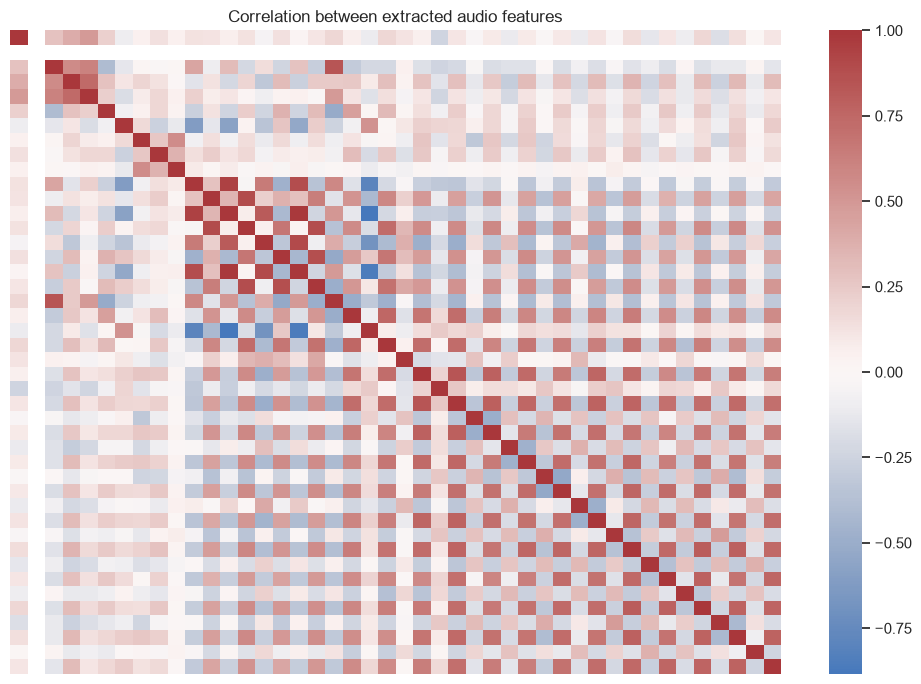

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(data=features_df, x="duration_seconds", hue="split", bins=25,
             element="step", common_norm=False, ax=axes[0])
axes[0].set(title="Recording duration", xlabel="Seconds", ylabel="Count")

sns.histplot(data=features_df, x="signal_rms_mean", hue="split", bins=25,
             element="step", common_norm=False, ax=axes[1])
axes[1].set(title="Mean frame-level RMS", xlabel="RMS amplitude", ylabel="Count")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
correlation = features_df[feature_columns].corr(numeric_only=True)
sns.heatmap(correlation, cmap="vlag", center=0, ax=ax, xticklabels=False, yticklabels=False)
ax.set(title="Correlation between extracted audio features")
plt.tight_layout()
plt.show()

9

In [9]:
train_features = features_df.loc[features_df["split"] == "train"].drop(columns="split").copy()
test_features = features_df.loc[features_df["split"] == "test"].drop(columns="split").copy()

train_features = train_df[["filename", "label"]].merge(
    train_features, on="filename", how="left", validate="one_to_one"
)
test_features = test_df[["filename"]].merge(
    test_features, on="filename", how="left", validate="one_to_one"
)

train_features.to_csv(FEATURE_DIR / "train_audio_features.csv", index=False)
test_features.to_csv(FEATURE_DIR / "test_audio_features.csv", index=False)

print("Training feature table:", train_features.shape)
print("Test feature table:", test_features.shape)
print("Training rows with missing feature values:",
      int(train_features.drop(columns=["filename", "label"]).isna().any(axis=1).sum()))
print("Test rows with missing feature values:",
      int(test_features.drop(columns=["filename"]).isna().any(axis=1).sum()))

Training feature table: (769, 46)
Test feature table: (216, 45)
Training rows with missing feature values: 0
Test rows with missing feature values: 0
